 **In this notebook,I try to analysis house price dataset and predict the house prices by regression methods.**
 **I start with introdusing the dataset,then I do data analysis and house price prediction step by step.**

# **Import the dataset:**

**This dataset have 1460 rows and 81 columns.The SalePrice is the target variable that I am trying to predict.At first I should import all necessary libraries and then read and import the dataset:**

In [1]:
import numpy as np #Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train=pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
#Cleaning the Id columns because it doesnt have important information.
train=train.drop("Id",axis=1)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

### **Target Value**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Sales data distribution')

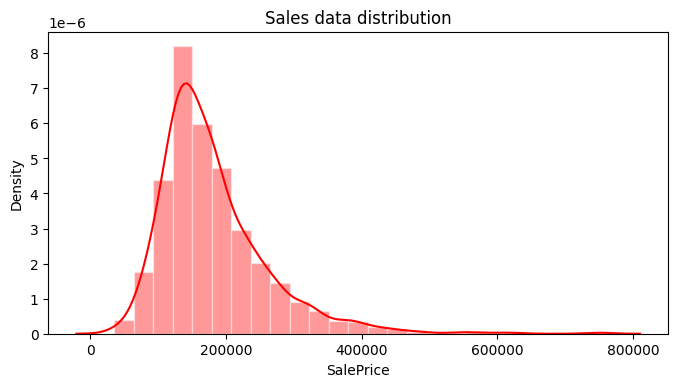

In [6]:
fig=plt.figure(figsize=(8,4),dpi=100)# Draw histogram for target variable
sns.distplot(train["SalePrice"],hist_kws=dict(edgecolor="w",linewidth=1),bins=25,color="r")
plt.title("Sales data distribution")

**As we see the most amount of prices are between 100000 to 300000.This SalePrice distribution is not very normal so I use log for that to make more normal distribution.**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Sales data distribution')

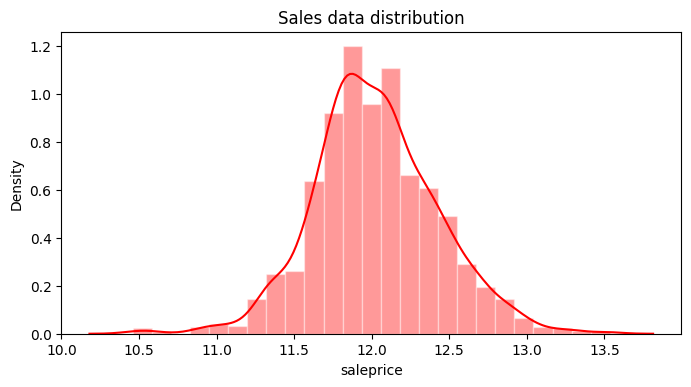

In [7]:
train['saleprice'] = np.log1p(train['SalePrice'])#Use log function in numpy

fig=plt.figure(figsize=(8,4),dpi=100)
sns.distplot(train["saleprice"],hist_kws=dict(edgecolor="w",linewidth=1),bins=25,color="r")
plt.title("Sales data distribution")

### **Checking Missing Data**
**Before I continue,I want to introduce the missing value briefly.The real-world data often has a lot of missing values. The cause of missing values can be data corruption or failure to record data.
The handling of missing data is very important during the preprocessing of the dataset as many machine learning algorithms do not support missing values.**
**Now I want to identify the rows with the most number of missing values and drop or transform them.**

In [8]:
#Let's check if the data set has any missing values.
100*(train.isnull().sum()/len(train))
def missing_values_percent(train):#we can use this function in all dataframes.
    nan_percent=100*(train.isnull().sum()/len(train))
    nan_percent=nan_percent[nan_percent>0].sort_values()
    return(nan_percent)



In [9]:
nan_percent=missing_values_percent(train)
nan_percent

Electrical       0.068493
MasVnrType       0.547945
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageCond       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'MasVnrType'),
  Text(2, 0, 'MasVnrArea'),
  Text(3, 0, 'BsmtQual'),
  Text(4, 0, 'BsmtCond'),
  Text(5, 0, 'BsmtFinType1'),
  Text(6, 0, 'BsmtExposure'),
  Text(7, 0, 'BsmtFinType2'),
  Text(8, 0, 'GarageCond'),
  Text(9, 0, 'GarageQual'),
  Text(10, 0, 'GarageFinish'),
  Text(11, 0, 'GarageType'),
  Text(12, 0, 'GarageYrBlt'),
  Text(13, 0, 'LotFrontage'),
  Text(14, 0, 'FireplaceQu'),
  Text(15, 0, 'Fence'),
  Text(16, 0, 'Alley'),
  Text(17, 0, 'MiscFeature'),
  Text(18, 0, 'PoolQC')])

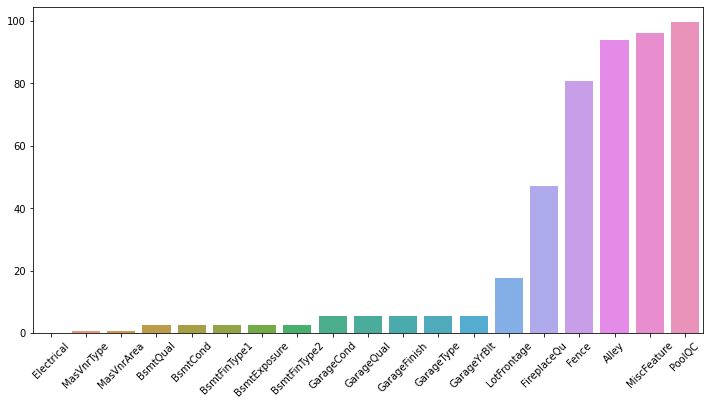

In [10]:
#Drawing barplot for these missing values.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

(0.0, 5.0)

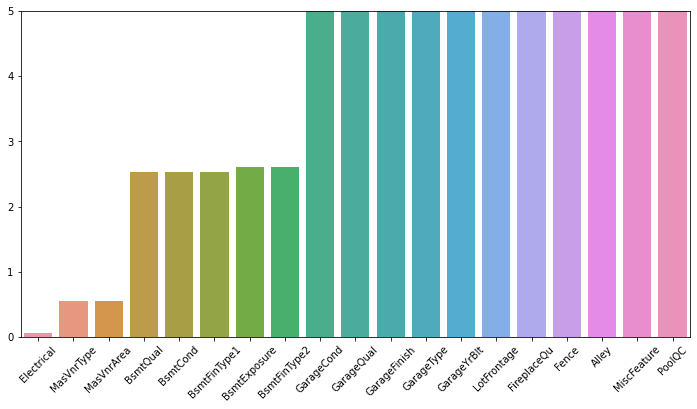

In [11]:
#determine the missing values that their percentages are between 0 and 5.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

plt.ylim(0,5)

## **In this step we want to make a decision about our missing data**

In [12]:
train[train["Electrical"].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,saleprice
1379,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,5,2008,WD,Normal,167500,12.028745


In [13]:
#can delet this row
train=train.drop(labels=1379,axis=0)

(0.0, 5.0)

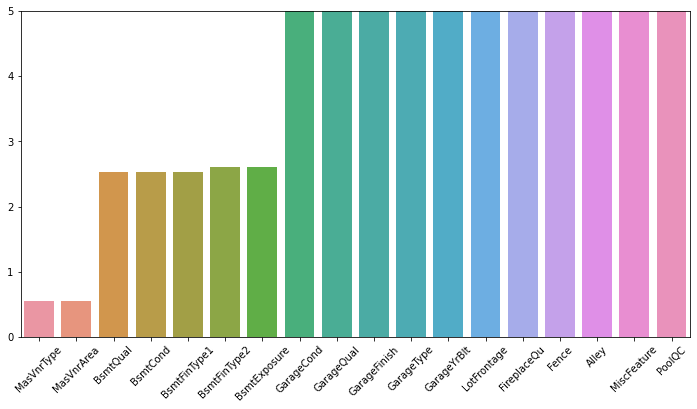

In [14]:
nan_percent=missing_values_percent(train)#see Electrical has been droped from missing data.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

plt.ylim(0,5)

In [15]:
train["MasVnrType"]=train["MasVnrType"].fillna("None")
train["MasVnrArea"]=train["MasVnrArea"].fillna(0)

(0.0, 5.0)

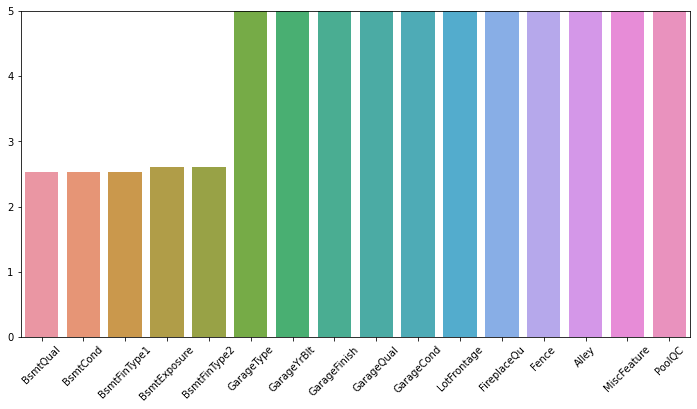

In [16]:
nan_percent=missing_values_percent(train)#see MasVnrType and MasVnrArea have been droped.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

plt.ylim(0,5)

In [17]:
bsmt_str_cols=["BsmtQual","BsmtCond","BsmtFinType1","BsmtExposure","BsmtFinType2"]
train[bsmt_str_cols]=train[bsmt_str_cols].fillna("None")

In [18]:
gar_str_cols=["GarageType","GarageFinish"]#transform the object to None
train[gar_str_cols]=train[gar_str_cols].fillna("None")

gar_num_cols=["GarageYrBlt","GarageQual","GarageCond"]#transform the int or float to 0
train[gar_num_cols]=train[gar_num_cols].fillna(0)

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'LotFrontage'),
  Text(1, 0, 'FireplaceQu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'MiscFeature'),
  Text(5, 0, 'PoolQC')])

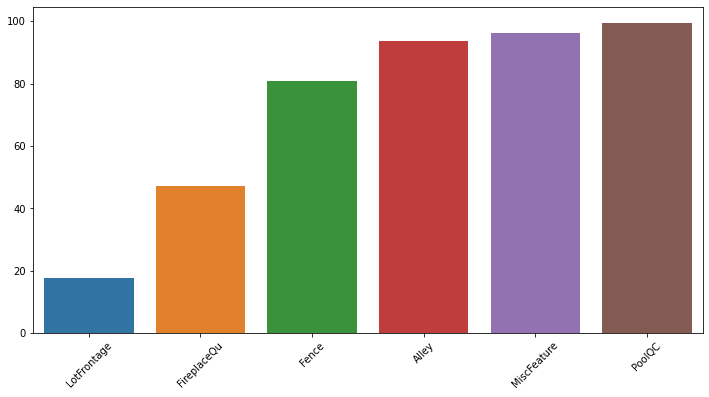

In [19]:
nan_percent=missing_values_percent(train)#see MasVnrType and MasVnrArea have been droped.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

In [20]:
train["FireplaceQu"]=train["FireplaceQu"].fillna("None")

**From the below boxplot we understand that any neighborhood have specefic LotFrontage distribution.So we can replace the average of Lotfrontage base on each Neighborhood with the missing data.**

<AxesSubplot:xlabel='LotFrontage', ylabel='Neighborhood'>

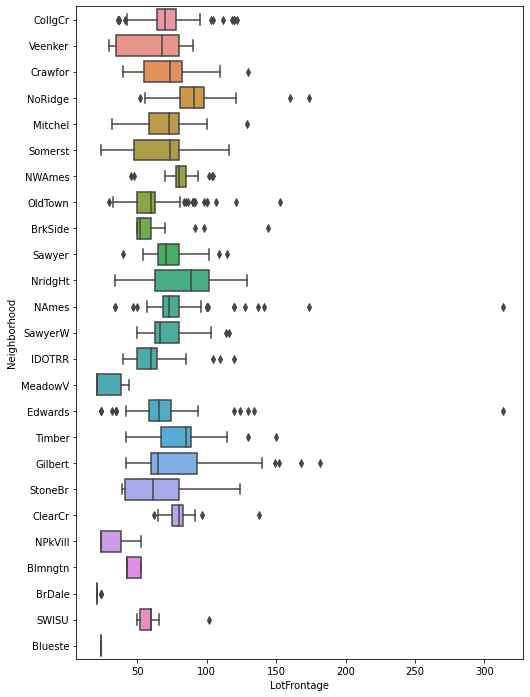

In [21]:
plt.figure(figsize=(8,12))
sns.boxplot(data=train,x="LotFrontage",y="Neighborhood")


In [22]:
train.groupby("Neighborhood")["LotFrontage"].mean()#average of Lotfrontage base on each Neighborhood

Neighborhood
Blmngtn    47.142857
Blueste    24.000000
BrDale     21.562500
BrkSide    57.509804
ClearCr    83.461538
CollgCr    71.682540
Crawfor    71.804878
Edwards    68.217391
Gilbert    79.877551
IDOTRR     62.500000
MeadowV    27.800000
Mitchel    70.083333
NAmes      76.462366
NPkVill    32.285714
NWAmes     81.288889
NoRidge    91.878788
NridgHt    81.881579
OldTown    62.788991
SWISU      58.913043
Sawyer     74.437500
SawyerW    71.500000
Somerst    64.666667
StoneBr    62.700000
Timber     80.379310
Veenker    59.714286
Name: LotFrontage, dtype: float64

In [23]:
#replace the average of Lotfrontage base on each Neighborhood with the missing data
train["LotFrontage"]=train.groupby("Neighborhood")["LotFrontage"].transform(lambda val:val.fillna(val.mean()))

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Fence'),
  Text(1, 0, 'Alley'),
  Text(2, 0, 'MiscFeature'),
  Text(3, 0, 'PoolQC')])

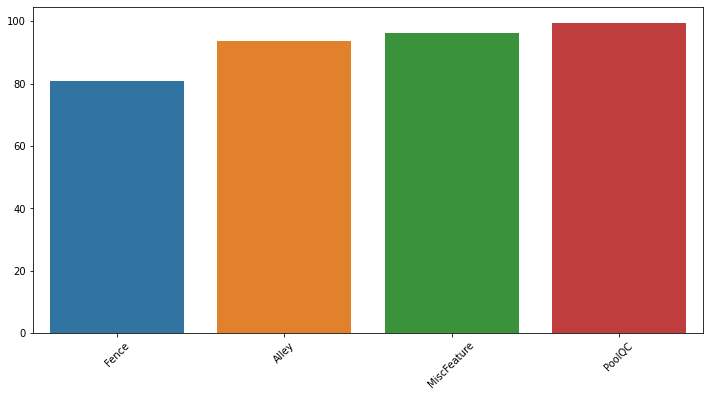

In [24]:
nan_percent=missing_values_percent(train)#see MasVnrType and MasVnrArea have been droped.
plt.figure(figsize=(12,6))
sns.barplot(x=nan_percent.index,y=nan_percent)
plt.xticks(rotation=45)

**As we see,we have only 4 features that have missing data.As the percentage of missing datas in these features are above 80%,the best way is to drop them from the dataframe.**

In [25]:
train=train.drop(["Fence","Alley","MiscFeature","PoolQC"],axis=1)

In [26]:
train.isnull().sum()#we have no missing data

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
saleprice        0
Length: 77, dtype: int64

## Now,we have no missing data.

In [27]:
train.corr()["saleprice"]#determine correlation

MSSubClass      -0.073971
LotFrontage      0.352773
LotArea          0.257321
OverallQual      0.817368
OverallCond     -0.036868
YearBuilt        0.586827
YearRemodAdd     0.565822
MasVnrArea       0.426828
BsmtFinSF1       0.372152
BsmtFinSF2       0.004835
BsmtUnfSF        0.222002
TotalBsmtSF      0.612642
1stFlrSF         0.597219
2ndFlrSF         0.319344
LowQualFinSF    -0.037962
GrLivArea        0.700942
BsmtFullBath     0.236285
BsmtHalfBath    -0.005147
FullBath         0.594892
HalfBath         0.314135
BedroomAbvGr     0.209044
KitchenAbvGr    -0.147549
TotRmsAbvGrd     0.534436
Fireplaces       0.489609
GarageYrBlt      0.349022
GarageCars       0.680645
GarageArea       0.650916
WoodDeckSF       0.334135
OpenPorchSF      0.321114
EnclosedPorch   -0.149054
3SsnPorch        0.054901
ScreenPorch      0.121213
PoolArea         0.069799
MiscVal         -0.020020
MoSold           0.057338
YrSold          -0.037264
SalePrice        0.948385
saleprice        1.000000
Name: salepr

# **Exploratory data analysis**

**This is not a very big data and we do not have too many features. Thus, we have chance to plot most of them and reach some useful analytical results. Drawing charts and examining the data before applying a model is a very good practice because we may detect some possible outliers or decide to do normalization.**

<AxesSubplot:xlabel='YrSold'>

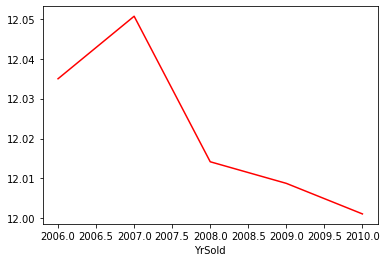

In [28]:
#we want to determine the relationship between saleprice and yearsold.
train.groupby("YrSold")["saleprice"].mean().plot(color="r")

### We see that the price is decreasing between 2006 to 2010,The highest saleprice belongs to 2007 then we have the sharp decreasing in 2008,I think it is weired because the price increases mainly over the years.

<AxesSubplot:>

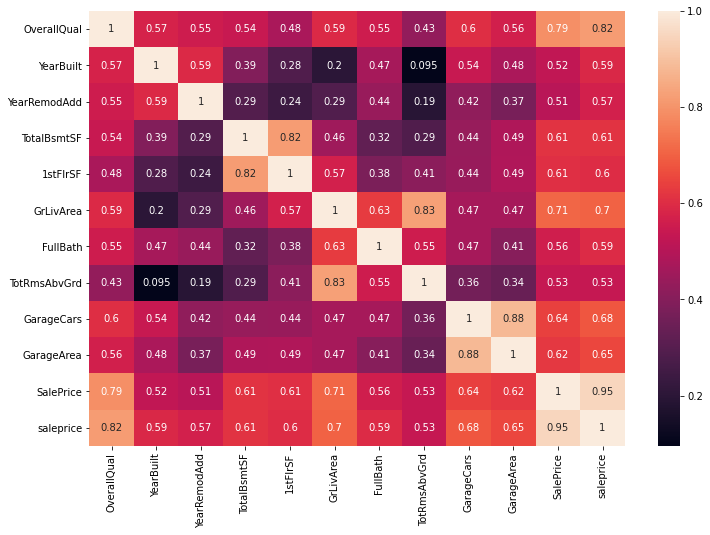

In [29]:
corr = train.corr()#Top 50% Corralation train attributes with sale-price
top_feature = corr.index[abs(corr['saleprice']>0.5)]
plt.subplots(figsize=(12, 8))
top_corr = train[top_feature].corr()
sns.heatmap(top_corr, annot=True)

### As we see ten features have the most value of correlation,**overallqual** with alomost 80% has the most value of correlation and the second one is Grlivearea with almost 70%.

## NOW I want to plot the 2 top features:

<AxesSubplot:xlabel='OverallQual', ylabel='saleprice'>

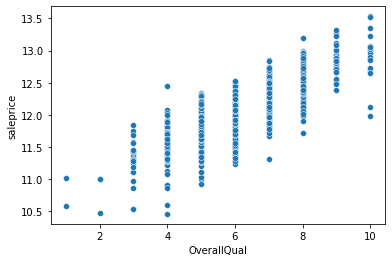

In [30]:
sns.scatterplot(data=train,x="OverallQual",y="saleprice")


**We see that the customer should pay more for high overallqual and they dont prefer to buy a house with the quality under 3.**

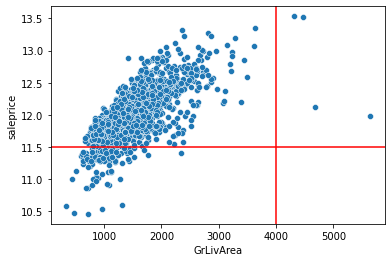

In [31]:
sns.scatterplot(data=train,x="GrLivArea",y="saleprice")
plt.axhline(y=11.5 , color="r")
plt.axvline(x=4000,color="r")

# we see that we have 4 *outliers* which we decide about them.

In [32]:
train[(train["GrLivArea"]>4000) & (train["saleprice"]>11.5)][["GrLivArea","saleprice"]]#determine the index of outliers

,GrLivArea,saleprice
523,4676,12.126764
691,4316,13.534474
1182,4476,13.521141
1298,5642,11.982935


In [33]:
index_drop=train[(train["GrLivArea"]>4000) & (train["saleprice"]>11.5)].index#drop the outliers
train=train.drop(index_drop,axis=0)

### Further, I drew the 3D plot to determine the relation between the saleprice, overallqual and year built. The below chart shows that the newer houses have the more overalqual but we can not say this about fullbath.

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  


Text(0.5, 0, 'OverallQual')

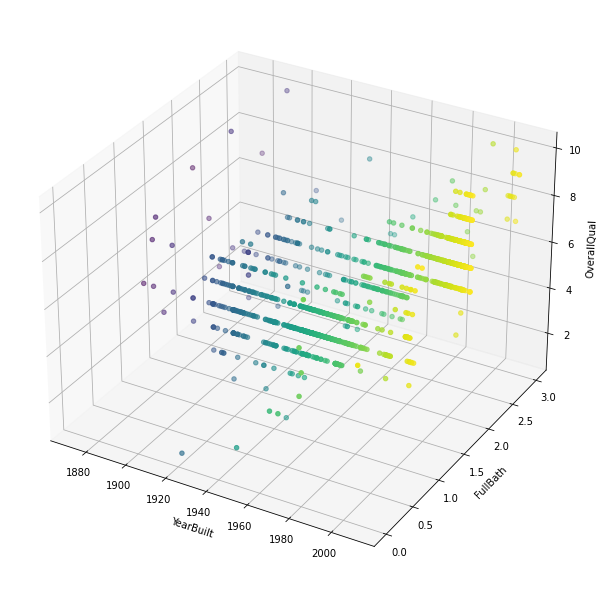

In [34]:

from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(8,8))

ax = Axes3D(fig) 

x = train["YearBuilt"]
y = train["FullBath"]
z = train["OverallQual"]


ax.scatter(x, y, z, c=x, marker='o')
ax.set_xlabel('YearBuilt')
ax.set_ylabel('FullBath')
ax.set_zlabel('OverallQual')


### **Categorical data**

**In this step,I want to encoding str to int.**

In [35]:
#At first,I tranform MSSubClass to str:
train["MSSubClass"].apply(str)

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1455, dtype: object

In [36]:
train.select_dtypes(include="object")#seperate the data that are object

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [37]:
#Divide dataframe to 2 parts(num and str)
train_num=train.select_dtypes(exclude="object")
train_obj=train.select_dtypes(include="object")

In [38]:
train_obj=pd.get_dummies(train_obj,drop_first=True)#use one-hot encoding to transform str to int and float
train_obj.shape

(1455, 209)

In [39]:
Final_train=pd.concat([train_num,train_obj],axis=1)

# **LinearRegression**

**Linear regression is probably one of the most important and widely used regression techniques. It’s among the simplest regression methods. One of its main advantages is the ease of interpreting results.
Linear regression performs the task to predict a dependent variable value (y) based on a given independent variable (x). So, this regression technique finds out a linear relationship between x (input) and y(output). Hence, the name is Linear Regression.**
**In this step we want to predict our target valuable (saleprice) based on our features.**

 **After import the data,data overview and exploratory data analysis which are shown,we should determine the feature and lable.**

In [40]:
#Determine the feature and lable
X=Final_train.drop("saleprice",axis=1)
y=Final_train["saleprice"]

In [41]:
#Split the dataset to train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [42]:
#train the model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [43]:
#coeficient matrix
pd.DataFrame(model.coef_,X.columns,columns=["coeficient"])

,coeficient
MSSubClass,0.000255
LotFrontage,0.000140
LotArea,0.000001
OverallQual,0.016850
OverallCond,0.022689
...,...
SaleCondition_AdjLand,0.036824
SaleCondition_Alloca,0.005430
SaleCondition_Family,0.007521
SaleCondition_Normal,0.038410


In [44]:
#predicting test data
y_pred=model.predict(X_test)

In [45]:
#evaluating the model
from sklearn import metrics
MAD=metrics.mean_absolute_error(y_test,y_pred)
MSE=metrics.mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)

In [46]:
pd.DataFrame(data=[MAD,MSE,RMSE],index=["MAD","MSE","RMSE"],columns=["LinearRegression"])

,LinearRegression
MAD,0.058122
MSE,0.008245
RMSE,0.090801


## **Residuals**

**For linear regression it is a good idea to evaluate residuals(y- ̂y)**


Text(0, 0.5, 'Y-Pred')

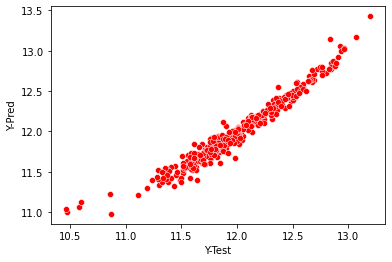

In [47]:
test_residuals=y_test-y_pred#the residuals should be random and close to normal distribution.
sns.scatterplot(x=y_test,y=y_pred,color="r")
plt.xlabel('Y-Test')
plt.ylabel('Y-Pred')

Text(0, 0.5, 'residuals')

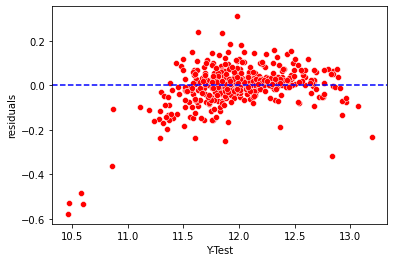

In [48]:
sns.scatterplot(x=y_test,y=test_residuals,color="r")#test residuals should not show a clear pattern.
plt.axhline(y=0,color="b",ls="--")
plt.xlabel('Y-Test')
plt.ylabel('residuals')

 ### **As we see ,the residuals show a clear pattern.so we can say,linear regression is not suitable for this model.**

# **Ridge regression**

**Ridge regression is a model tuning method that is used to analyse any data that suffers from multicollinearity. This method performs L2 regularization. When the issue of multicollinearity occurs, least-squares are unbiased, and variances are large, this results in predicted values to be far away from the actual values.**

In [49]:
from sklearn.linear_model import Ridge

In [50]:
ridge_model=Ridge(alpha=10)

In [51]:
ridge_model.fit(X_train,y_train)

Ridge(alpha=10)

Ridge regression

In [52]:
y_pred=ridge_model.predict(X_test)

In [53]:
from sklearn import metrics
MAD3=metrics.mean_absolute_error(y_test,y_pred)
MSE3=metrics.mean_squared_error(y_test,y_pred)
RMSE3=np.sqrt(MSE3)

In [54]:
data={'LinearRegression':[MAD,MSE,RMSE],"Ridge regression":[MAD3,MSE3,RMSE3]}
pd.DataFrame(data,index=["MAD","MSE","RMSE"])

,LinearRegression,Ridge regression
MAD,0.058122,0.053141
MSE,0.008245,0.007673
RMSE,0.090801,0.087594


## **Ridgecv(cross validation)**

**Cross-validation** is a statistical method used to estimate the skill of machine learning models.

It is commonly used in applied machine learning to compare and select a model for a given predictive modeling problem because it is easy to understand, easy to implement, and results in skill estimates that generally have a lower bias than other methods.

In [55]:
from sklearn.linear_model import RidgeCV

In [56]:
from sklearn.linear_model import RidgeCV

In [57]:
ridge_cv_model=RidgeCV(alphas=(0.1, 1.0, 10.0),scoring="neg_mean_absolute_error")

In [58]:
ridge_cv_model.fit(X_train,y_train)

RidgeCV(alphas=array([ 0.1,  1. , 10. ]), scoring='neg_mean_absolute_error')

In [59]:
ridge_cv_model.alpha_

10.0

In [60]:
y_pred_ridge=ridge_cv_model.predict(X_test)

In [61]:
from sklearn import metrics
MAD4=metrics.mean_absolute_error(y_test,y_pred_ridge)
MSE4=metrics.mean_squared_error(y_test,y_pred_ridge)
RMSE4=np.sqrt(MSE4)

In [62]:
data={'LinearRegression':[MAD,MSE,RMSE],"Ridge regression":[MAD3,MSE3,RMSE3],"Ridgecv":[MAD4,MSE4,RMSE4]}
pd.DataFrame(data,index=["MAD","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv
MAD,0.058122,0.053141,0.053139
MSE,0.008245,0.007673,0.007672
RMSE,0.090801,0.087594,0.087591


# **Lasso regression**

**Lasso regression is a regularization technique. It is used over regression methods for a more accurate prediction. This model uses shrinkage. Shrinkage is where data values are shrunk towards a central point as the mean. The lasso procedure encourages simple, sparse models (i.e. models with fewer parameters)**

In [63]:
from sklearn.linear_model import LassoCV

In [64]:
lasso_cv_model=LassoCV(eps=0.1,n_alphas=100,cv=5)

In [65]:
lasso_cv_model.fit(X_train,y_train)

LassoCV(cv=5, eps=0.1)

In [66]:
lasso_cv_model.alpha_

2916.6511184422584

In [67]:
y_pred_lasso=lasso_cv_model.predict(X_test)

In [68]:
from sklearn import metrics
MAD5=metrics.mean_absolute_error(y_test,y_pred_lasso)
MSE5=metrics.mean_squared_error(y_test,y_pred_lasso)
RMSE5=np.sqrt(MSE5)

In [69]:
data={'LinearRegression':[MAD,MSE,RMSE],"Ridge regression":[MAD3,MSE3,RMSE3],"Ridgecv":[MAD4,MSE4,RMSE4],"Lassocv":[MAD5,MSE5,RMSE5]}
pd.DataFrame(data,index=["MAD","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv,Lassocv
MAD,0.058122,0.053141,0.053139,0.086575
MSE,0.008245,0.007673,0.007672,0.018437
RMSE,0.090801,0.087594,0.087591,0.135785


# **Elastic Net**

**Elastic net is a popular type of regularized linear regression that combines two popular penalties, specifically the L1 and L2 penalty functions. ... Elastic Net is an extension of linear regression that adds regularization penalties to the loss function during training.**

In [70]:
from sklearn .linear_model import ElasticNetCV
elastic_model=ElasticNetCV(l1_ratio=[0.1,0.5,0.7,0.9,0.95,0.99,1],cv=5,max_iter=100000)

In [71]:
elastic_model.fit(X_train,y_train)
elastic_model.l1_ratio_

0.1

In [72]:
y_pred_elastic=elastic_model.predict(X_test)

In [73]:
from sklearn import metrics
MAD6=metrics.mean_absolute_error(y_test,y_pred_elastic)
MSE6=metrics.mean_squared_error(y_test,y_pred_elastic)
RMSE6=np.sqrt(MSE6)

In [74]:
data={'LinearRegression':[MAD,MSE,RMSE],"Ridge regression":[MAD3,MSE3,RMSE3],"Ridgecv":[MAD4,MSE4,RMSE4],"Lassocv":[MAD5,MSE5,RMSE5],"elasticnet":[MAD6,MSE6,RMSE6]}
pd.DataFrame(data,index=["MAD","MSE","RMSE"])

,LinearRegression,Ridge regression,Ridgecv,Lassocv,elasticnet
MAD,0.058122,0.053141,0.053139,0.086575,0.078795
MSE,0.008245,0.007673,0.007672,0.018437,0.015633
RMSE,0.090801,0.087594,0.087591,0.135785,0.125034


# **From my opinin,as the residuals show the clear pattern in linear regression,according to the RMSE error the ridgecv is the best method in this model.**